# 1.Tiktok GRAPH CONSTRUCTION

POST-POST HOMOPHILY GRAPH

In [142]:
import pandas as pd
import networkx as nx
from itertools import combinations

# =====================================================
# LOAD TIKTOK GRAPH DATASET
# =====================================================

df = pd.read_csv(
    "../../data_preprocess/processed_data/graph_data/tiktok_graph.csv"
)

print("=" * 60)
print("TIKTOK GRAPH DATA")
print("=" * 60)

print(df.shape)

TIKTOK GRAPH DATA
(11887, 30)


In [143]:
import pandas as pd
import numpy as np
import time

overall_start = time.time()

# =====================================================
# 1. GENERATE NODES
# =====================================================
print("Creating Nodes for TikTok...")
nodes_df = df.copy().rename(columns={"post_id": "Id"})
nodes_df["Label"] = nodes_df["Id"]

# Export Node file
nodes_df.to_csv("tiktok_node.csv", index=False, encoding='utf-8')

# =====================================================
# 2. GENERATE EDGES (TIKTOK INTEREST GRAPH)
# =====================================================
edges_list = []

sorted_df = df.sort_values(by=['followers'], ascending=True)

# --- A. Common Interests & Language Clusters ---
# Tiktok distributes content based on "interest clusters".
# Basing on Top Feature: Sports, Finance, Science, Health and Hindi, Korean
cat_features = ['topic', 'language']

for feat in cat_features:
    if feat not in sorted_df.columns: continue
    print(f"Processing TikTok Interest Clusters: {feat}...")
    
    for val, group in sorted_df.groupby(feat):
        if pd.isna(val): continue
        ids = group['post_id'].values
        if len(ids) < 2: continue
        
        for i in range(len(ids) - 1):
            if val in ['Sports', 'Finance', 'Science', 'Hindi', 'Korean']:
                weight = 1.8 
            else:
                weight = 1.2
                
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": weight, 
                "Relation": feat
            })

# --- B. VERIFIED - TOP 2 IMPORTANCE ---
if 'verified' in sorted_df.columns:
    print("Processing TikTok Verified Creator Network...")
    verified_group = sorted_df[sorted_df['verified'] == 1]
    ids = verified_group['post_id'].values
    
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 1.5, 
                "Relation": "verified_hub"
            })

# --- C. SENTIMENT INTENSITY - TOP 4 IMPORTANCE ---
if 'sentiment_intensity' in sorted_df.columns:
    print("Processing TikTok Energy/Vibe Homophily...")
    temp_df = sorted_df.copy()
    temp_df['energy_bins'] = temp_df['sentiment_intensity'].round(1)
    
    for val, group in temp_df.groupby('energy_bins'):
        ids = group['post_id'].values
        if len(ids) < 2: continue
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 1.0, 
                "Relation": "energy_vibe"
            })

# --- D. IS_WEEKEND - TOP 15 ---
if 'is_weekend' in sorted_df.columns:
    print("Processing TikTok Weekend Binge Watch...")
    weekend_group = sorted_df[sorted_df['is_weekend'] == 1]
    ids = weekend_group['post_id'].values
    
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 0.8, 
                "Relation": "weekend_trend"
            })

# --- E. SAME CREATOR ---
print("Processing TikTok Creator Bridges...")
for user_id, group in sorted_df.groupby('user_id'):
    ids = group['post_id'].values
    if len(ids) >= 2:
        for i in range(len(ids) - 1):
            edges_list.append({
                "Source": ids[i], 
                "Target": ids[i+1],
                "Weight": 2.5, 
                "Relation": "same_creator"
            })

# =====================================================
# 3. CLEAN & EXPORT
# =====================================================
edges_df = pd.DataFrame(edges_list)
if not edges_df.empty:
    edges_df[['Source', 'Target']] = np.sort(edges_df[['Source', 'Target']], axis=1)
    edges_df = edges_df.drop_duplicates(subset=['Source', 'Target', 'Relation'])
    edges_df = edges_df[edges_df['Source'] != edges_df['Target']]

edges_df.to_csv("tiktok_edge.csv", index=False, encoding='utf-8')

print(f"\n--- TIKTOK GRAPH ---")
print(f"Nodes: {len(nodes_df):,}")
print(f"Edges: {len(edges_df):,}")
print(f"Time: {round(time.time() - overall_start, 2)}s")

Creating Nodes for TikTok...
Processing TikTok Interest Clusters: topic...
Processing TikTok Interest Clusters: language...
Processing TikTok Verified Creator Network...
Processing TikTok Energy/Vibe Homophily...
Processing TikTok Weekend Binge Watch...
Processing TikTok Creator Bridges...

--- TIKTOK GRAPH ---
Nodes: 11,887
Edges: 39,322
Time: 1.04s


In [166]:
import pandas as pd

graph_df = pd.read_csv(
    "tiktok-result.csv"
)

print("\n" + "=" * 60)
print("GRAPH FEATURES DATA")
print("=" * 60)

print(graph_df.shape)

print("\nColumns:")
print(graph_df.columns.tolist())


GRAPH FEATURES DATA
(11887, 45)

Columns:
['Id', 'Label', 'platform', 'hour_of_day', 'day_of_week', 'is_weekend', 'user_id', 'followers', 'account_age_days', 'verified', 'topic', 'language', 'content_length', 'media_type', 'num_hashtags', 'sentiment_category', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'toxicity_score', 'location', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'has_media', 'many_hashtags', 'long_content', 'sentiment_intensity', 'high_toxicity', 'popularity', 'Degree', 'Weighted Degree', 'Authority', 'Hub', 'pageranks', 'componentnumber', 'modularity_class', 'clustering', 'triangles', 'eigencentrality', 'Eccentricity', 'closnesscentrality', 'harmonicclosnesscentrality', 'betweenesscentrality']


In [168]:
# SELECT ONLY USEFUL GRAPH FEATURES
# =====================================================

graph_features = graph_df[[
    "Id",
    "Authority", 
    "Hub", 
    "pageranks", 
    "modularity_class", 
    "eigencentrality", 
]]
graph_features = graph_features.rename(
    columns={
        "Id": "post_id"
    }
)

print("\nGraph Features Shape:")
print(graph_features.shape)



Graph Features Shape:
(11887, 6)


In [169]:
original_df = df.copy()

# =====================================================
# REMOVE DUPLICATES
# =====================================================

original_df = original_df.drop_duplicates(
    subset=["post_id"]
)

In [170]:
# MERGE POST_ID BACK TO TRAIN/TEST
# =====================================================
# We need mapping between rows
# =====================================================

# recreate metadata version
metadata_df = original_df.copy()

remove_cols = [
    
    "timestamp",
    "date",
    "platform",
    "likes",
    "shares",
    "comments",
    "views",
    "total_engagement",
    "engagement_rate_per_1k_followers",
    "viral_coefficient",
    "cross_platform_spread",
    "hours_since_post"
]

existing_remove_cols = [

    col for col in remove_cols
    if col in metadata_df.columns
]

metadata_df = metadata_df.drop(
    columns=existing_remove_cols
)


In [171]:
# =====================================================
# ONE-HOT ENCODING
# =====================================================

categorical_cols = [

    "topic",
    "language",
    "media_type",
    "sentiment_category",
    "location"
]

existing_categorical_cols = [

    col for col in categorical_cols
    if col in metadata_df.columns
]

metadata_df = pd.get_dummies(

    metadata_df,

    columns=existing_categorical_cols,

    drop_first=True
)


In [172]:
# LOAD TIKTOK TRAIN / TEST
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/tiktok_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/tiktok_test.csv"
)

print("=" * 60)
print("METADATA DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATASETS
Train Shape: (9509, 56)
Test Shape : (2378, 56)


In [173]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

In [174]:

print("\n" + "="*30)
print("Class distribution in the training set")
print("="*30)
print(train_df["popularity"].value_counts())
print("\nRatio %:")
print(train_df["popularity"].value_counts(normalize=True) * 100)

print("\n" + "="*30)
print("Class distribution in the test set")
print("="*30)
print(test_df["popularity"].value_counts())
print("\nRatio %:")
print(test_df["popularity"].value_counts(normalize=True) * 100)


Class distribution in the training set
popularity
0    7607
1    1902
Name: count, dtype: int64

Ratio %:
popularity
0    79.997897
1    20.002103
Name: proportion, dtype: float64

Class distribution in the test set
popularity
0    1902
1     476
Name: count, dtype: int64

Ratio %:
popularity
0    79.983179
1    20.016821
Name: proportion, dtype: float64


In [175]:

negative_count = train_df["popularity"].value_counts()[0]
positive_count = train_df["popularity"].value_counts()[1]

ratio = negative_count / positive_count
print(f"Class imbalance detected! scale_pos_weight = {ratio:.2f}")

Class imbalance detected! scale_pos_weight = 4.00


In [176]:
# FILL MISSING VALUES IN GRAPH FEATURES
# =====================================================

numeric_graph_cols = [
    "Authority", 
    "Hub", 
    "pageranks", 
    "modularity_class", 
    "eigencentrality", 
]

existing_numeric_cols = [col for col in numeric_graph_cols if col in train_hybrid.columns]

train_hybrid[existing_numeric_cols] = train_hybrid[existing_numeric_cols].fillna(0)
test_hybrid[existing_numeric_cols]  = test_hybrid[existing_numeric_cols].fillna(0)

X_train_cols = train_hybrid.columns
test_hybrid = test_hybrid.reindex(columns=X_train_cols, fill_value=0)

print("\n" + "=" * 60)
print("HYBRID DATASETS - CLEANED & ALIGNED")
print("=" * 60)
print(f"Train Hybrid: {train_hybrid.shape}")
print(f"Test Hybrid : {test_hybrid.shape}")


HYBRID DATASETS - CLEANED & ALIGNED
Train Hybrid: (9509, 61)
Test Hybrid : (2378, 61)


In [177]:
# SAVE HYBRID DATASETS
# =====================================================

train_hybrid.to_csv(
    "tiktok_hybrid_train.csv",
    index=False
)

test_hybrid.to_csv(
    "tiktok_hybrid_test.csv",
    index=False
)

In [178]:
# =====================================================
# TIKTOK HYBRID MODEL
# METADATA + GRAPH FEATURES
# =====================================================

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [179]:
# LOAD HYBRID DATASETS
# =====================================================

train_df = pd.read_csv(
    "tiktok_hybrid_train.csv"
)

test_df = pd.read_csv(
    "tiktok_hybrid_test.csv"
)

print("=" * 60)
print("HYBRID DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

HYBRID DATASETS
Train Shape: (9509, 61)
Test Shape : (2378, 61)


In [180]:
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_df.columns
]

train_df = train_df.drop(
    columns=existing_drop_cols
)

test_df = test_df.drop(
    columns=existing_drop_cols
)

In [181]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_df.drop(
    columns=["popularity"]
)

y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=["popularity"]
)

y_test = test_df["popularity"]

print("\nX_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)


X_train Shape: (9509, 58)
X_test Shape : (2378, 58)


In [182]:
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     # Handle imbalanced data
    n_estimators=500,           # Number of boosting rounds
    learning_rate=0.02,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=1,         # Minimum sum of instance weight
    gamma=0.1,                  # Minimum loss reduction
    subsample=0.8,              # Fraction of training data per tree
    colsample_bytree=0.5,       # Fraction of features per tree
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all CPU cores
)

In [183]:
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)


TRAINING HYBRID MODEL...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [184]:
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [185]:
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [186]:
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      1902
           1       0.51      0.77      0.61       476

    accuracy                           0.81      2378
   macro avg       0.72      0.79      0.74      2378
weighted avg       0.85      0.81      0.82      2378

ROC-AUC  : 0.8708


In [187]:
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


CONFUSION MATRIX
[[1550  352]
 [ 109  367]]


In [188]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                feature  importance
3             followers    0.161313
5              verified    0.066842
56     modularity_class    0.049323
54                  Hub    0.035742
53            Authority    0.031151
38       language_Hindi    0.016676
25        topic_Finance    0.015784
24        topic_Fashion    0.015237
39    language_Japanese    0.014918
57      eigencentrality    0.014851
26           topic_Food    0.014685
55            pageranks    0.014559
18  sentiment_intensity    0.014189
16        many_hashtags    0.014121
8    sentiment_positive    0.014082
4      account_age_days    0.013989
9    sentiment_negative    0.013955
46     media_type_Video    0.013688
40      language_Korean    0.013514
31         topic_Sports    0.013510


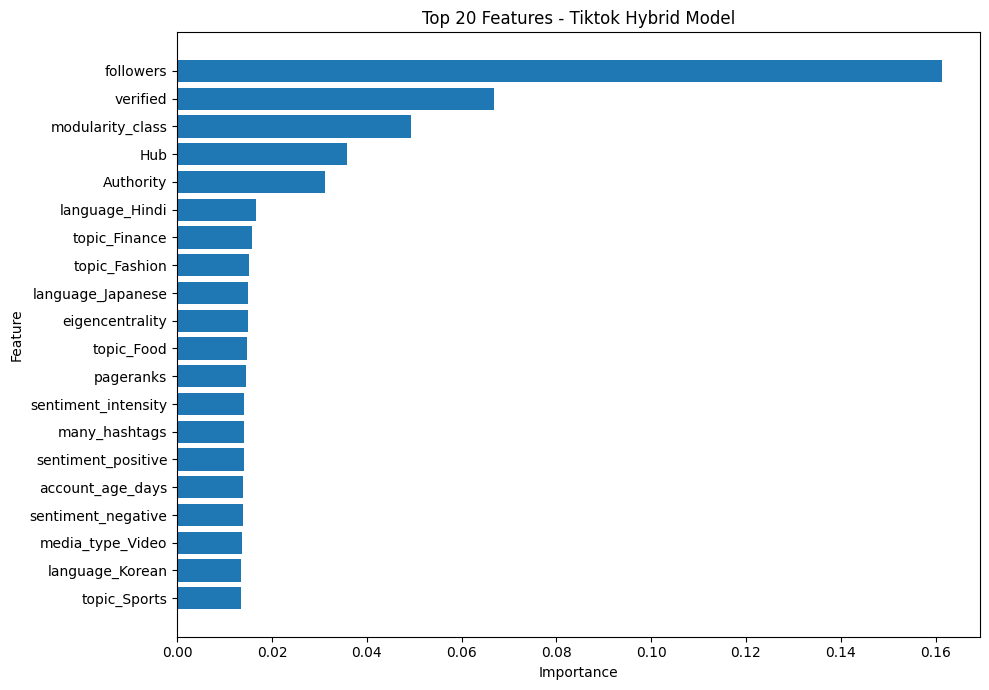

In [189]:
# PLOT TOP FEATURES
# =====================================================
import matplotlib.pyplot as plt

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 Features - Tiktok Hybrid Model"
)

plt.tight_layout()

plt.show()

# 2. TIKTOK NODE2VEC

 GRAPH EMBEDDING

In [190]:
import pandas as pd
import os
import networkx as nx

import time

start_time = time.time()

# 1. Just load edges, nodes
# =====================================================
print("Loading file Edges...")
edges_df = pd.read_csv("tiktok_edge.csv") 

# 2. Building NetworkX Graph...
# =====================================================
print("Building NetworkX Graph...")
G = nx.from_pandas_edgelist(
    edges_df, 
    source="Source", 
    target="Target", 
    create_using=nx.Graph() 
)

print(f"Graph Created  | Nodes: {G.number_of_nodes():,} | Edges: {G.number_of_edges():,}")


print("TRAINING NODE2VEC (MULTI-CORE)...")


so_loi_cpu = os.cpu_count()
print(f" Your laptop has {so_loi_cpu} CPU cores. Mobilizing all cores... " )

print("\n" + "=" * 60)
print("TRAINING NODE2VEC (MULTI-CORE UPDATE)...")
print("=" * 60)



Loading file Edges...
Building NetworkX Graph...
Graph Created  | Nodes: 11,887 | Edges: 35,359
TRAINING NODE2VEC (MULTI-CORE)...
 Your laptop has 16 CPU cores. Mobilizing all cores... 

TRAINING NODE2VEC (MULTI-CORE UPDATE)...


In [191]:
from node2vec import Node2Vec
import time

node2vec = Node2Vec(
    G,
    dimensions=8,        
    walk_length=10,      
    num_walks=20,        
    workers=so_loi_cpu,  
    seed=42,
    quiet=False          
)

model = node2vec.fit(
    window=5, 
    min_count=1, 
    batch_words=4     
)

print("\nNode2Vec done")

print(f"\nNode2Vec done after: {round((time.time() - start_time)/60, 2)} minutes ")



Computing transition probabilities:   0%|          | 0/11887 [00:00<?, ?it/s]


Node2Vec done

Node2Vec done after: 4.3 minutes 


In [192]:
# 4.Split and save vectors 
# =====================================================
print("Exporting Embeddings to DataFrame...")

node_ids = list(model.wv.index_to_key)
embeddings = model.wv.vectors

emb_df = pd.DataFrame(embeddings, columns=[f"emb_{i}" for i in range(8)])
emb_df["post_id"] = node_ids 

emb_df = emb_df[emb_df['post_id'].astype(str).str.startswith('TIK')]


emb_df.to_csv("tiktok_node2vec_8dims.csv", index=False)
print(f"Successfully saved {len(emb_df)} vectors of Post articles!")

Exporting Embeddings to DataFrame...
Successfully saved 11887 vectors of Post articles!


In [193]:
# TIKTOK NODE2VEC HYBRID MODEL
# METADATA + NODE2VEC EMBEDDINGS
# =====================================================

import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import matplotlib.pyplot as plt

In [194]:
# LOAD TRAIN / TEST DATA
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/tiktok_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/tiktok_test.csv"
)

print("=" * 60)
print("METADATA DATA")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATA
Train Shape: (9509, 56)
Test Shape : (2378, 56)


In [195]:
#LOAD NODE2VEC EMBEDDINGS
# =====================================================

embedding_df = pd.read_csv(
    "tiktok_node2vec_8dims.csv"
)

print("\n" + "=" * 60)
print("NODE2VEC EMBEDDINGS")
print("=" * 60)

print(embedding_df.shape)

print("\nEmbedding Columns:")
print(embedding_df.columns[:10])


NODE2VEC EMBEDDINGS
(11887, 9)

Embedding Columns:
Index(['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7',
       'post_id'],
      dtype='object')


In [196]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# CHECK MISSING VALUES
# =====================================================

print("\n" + "=" * 60)
print("MISSING EMBEDDINGS CHECK")
print("=" * 60)

embedding_cols = [

    col for col in embedding_df.columns
    if col.startswith("n2v_")
]

print("\nTrain Missing:")

print(
    train_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

print("\nTest Missing:")

print(
    test_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

# =====================================================
# FILL MISSING EMBEDDINGS
# =====================================================

train_hybrid[embedding_cols] = train_hybrid[
    embedding_cols
].fillna(0)

test_hybrid[embedding_cols] = test_hybrid[
    embedding_cols
].fillna(0)

# =====================================================
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_hybrid.columns
]

train_hybrid = train_hybrid.drop(
    columns=existing_drop_cols
)

test_hybrid = test_hybrid.drop(
    columns=existing_drop_cols
)


MISSING EMBEDDINGS CHECK

Train Missing:
0.0

Test Missing:
0.0


In [197]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_hybrid.drop(
    columns=["popularity"]
)

y_train = train_hybrid["popularity"]

X_test = test_hybrid.drop(
    columns=["popularity"]
)

y_test = test_hybrid["popularity"]

print("\n" + "=" * 60)
print("FINAL DATA")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)



FINAL DATA
X_train: (9509, 61)
X_test : (2378, 61)


In [198]:
# =====================================================
# XGBOOST MODEL

from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    
    scale_pos_weight=ratio,      
    
    # Optimized hyperparameters based on previous tuning
    n_estimators=300,            
    learning_rate=0.05,          
    max_depth=5,                
    subsample=0.8,               
    colsample_bytree=0.5,        
    colsample_bylevel=0.5,
    reg_alpha=1.0,               
    reg_lambda=2.0,              
    random_state=42,
    n_jobs=-1
)
# =====================================================
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING NODE2VEC HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("Training completed ")

# =====================================================
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

# =====================================================
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


TRAINING NODE2VEC HYBRID MODEL...
Training completed 


In [199]:
# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      1902
           1       0.48      0.76      0.59       476

    accuracy                           0.79      2378
   macro avg       0.71      0.78      0.72      2378
weighted avg       0.84      0.79      0.80      2378

ROC-AUC  : 0.8698


In [200]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                feature  importance
3             followers    0.188834
5              verified    0.107846
55                emb_2    0.030961
56                emb_3    0.023463
58                emb_5    0.021315
59                emb_6    0.019841
60                emb_7    0.019525
57                emb_4    0.017638
54                emb_1    0.017499
53                emb_0    0.014547
35     language_English    0.013787
10       toxicity_score    0.013703
25        topic_Finance    0.013676
16        many_hashtags    0.013482
9    sentiment_negative    0.013244
8    sentiment_positive    0.013183
18  sentiment_intensity    0.012980
28         topic_Health    0.012892
38       language_Hindi    0.012343
4      account_age_days    0.012168


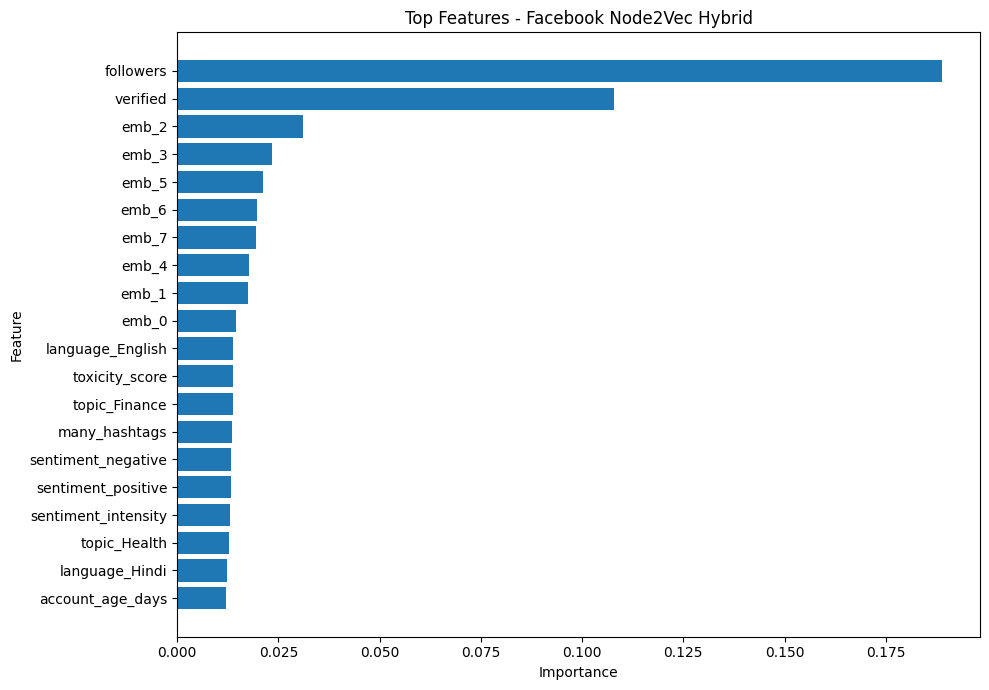

In [201]:
# =====================================================

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top Features - Facebook Node2Vec Hybrid"
)

plt.tight_layout()

plt.show()

# 3. Facebook graph + Node2vector

In [202]:
selected_n2v = ["emb_5", "emb_7", "emb_2", "emb_3", "emb_6", "emb_4", "emb_0", "emb_1"]

embedding_df_filtered = embedding_df[["post_id"] + [c for c in selected_n2v if c in embedding_df.columns]]

print("---  Done to filter Embeddings  ---")
print(f"Using columns: {embedding_df_filtered.columns.tolist()}")

---  Done to filter Embeddings  ---
Using columns: ['post_id', 'emb_5', 'emb_7', 'emb_2', 'emb_3', 'emb_6', 'emb_4', 'emb_0', 'emb_1']


In [203]:
train_df = pd.read_csv(
    "tiktok_hybrid_train.csv"
)

test_df = pd.read_csv(
    "tiktok_hybrid_test.csv"
)

print("=" * 60)
print("GRAPH HYBRID DATA")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

# =====================================================
# LOAD NODE2VEC EMBEDDINGS
# =====================================================

print("\n" + "=" * 60)
print("NODE2VEC EMBEDDINGS")
print("=" * 60)

print(embedding_df.shape)

# =====================================================
# CHECK EMBEDDING KEY
# =====================================================

print("\nEmbedding Columns:")
print(embedding_df.columns)


GRAPH HYBRID DATA
Train Shape: (9509, 61)
Test Shape : (2378, 61)

NODE2VEC EMBEDDINGS
(11887, 9)

Embedding Columns:
Index(['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7',
       'post_id'],
      dtype='object')


In [204]:
# 2. MERGE INTO DATA HYBRID 
# =====================================================
# Merge into Train set
train_final = train_df.merge(embedding_df_filtered, on="post_id", how="left")

# Merge into Test set
test_final = test_df.merge(embedding_df_filtered, on="post_id", how="left")

print(f"\n---  Done merging Embeddings  ---")
print(f"Train Shape: {train_final.shape} | Test Shape: {test_final.shape}")


---  Done merging Embeddings  ---
Train Shape: (9509, 69) | Test Shape: (2378, 69)


In [205]:
# 3. Process missing values
actual_emb_cols = [col for col in train_final.columns if col.startswith("emb_")]

print(f"\n Checking missing values for {len(actual_emb_cols)} embedding columns...")

train_final[actual_emb_cols] = train_final[actual_emb_cols].fillna(0)
test_final[actual_emb_cols] = test_final[actual_emb_cols].fillna(0)

print(f"Missing values after fill: {train_final[actual_emb_cols].isnull().sum().sum()}")


 Checking missing values for 8 embedding columns...
Missing values after fill: 0


In [206]:
# =====================================================
# 4. DROP COLUMNS (POST_ID, USER_ID)
# =====================================================
drop_cols = ["post_id", "user_id"]
existing_drop_cols = [col for col in drop_cols if col in train_final.columns]

train_final = train_final.drop(columns=existing_drop_cols)
test_final = test_final.drop(columns=existing_drop_cols)

print(f"\n--- Done ---")
print(f"Final number of features: {train_final.shape[1]} features.")


--- Done ---
Final number of features: 67 features.


In [207]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_final.drop(
    columns=["popularity"]
)

y_train = train_final["popularity"]

X_test = test_final.drop(
    columns=["popularity"]
)

y_test = test_final["popularity"]

print("\n" + "=" * 60)
print("FINAL FEATURE SPACE")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


FINAL FEATURE SPACE
X_train: (9509, 66)
X_test : (2378, 66)


In [208]:
# XGBOOST MODEL
# =====================================================

# XGBOOST MODEL
from xgboost import XGBClassifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     # Handle imbalanced data
    n_estimators=500,           # Number of boosting rounds
    learning_rate=0.02,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=1,         # Minimum sum of instance weight
    gamma=0.1,                  # Minimum loss reduction
    subsample=0.8,              # Fraction of training data per tree
    colsample_bytree=0.7,       # Fraction of features per tree
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all CPU cores
)

# =====================================================
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING FINAL FACEBOOK META + GRAPH + EMBEDDING...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("\nTraining completed ")

# =====================================================
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


TRAINING FINAL FACEBOOK META + GRAPH + EMBEDDING...

Training completed 


In [209]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


In [210]:


# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      1902
           1       0.50      0.75      0.60       476

    accuracy                           0.80      2378
   macro avg       0.72      0.78      0.73      2378
weighted avg       0.84      0.80      0.81      2378

ROC-AUC  : 0.8733


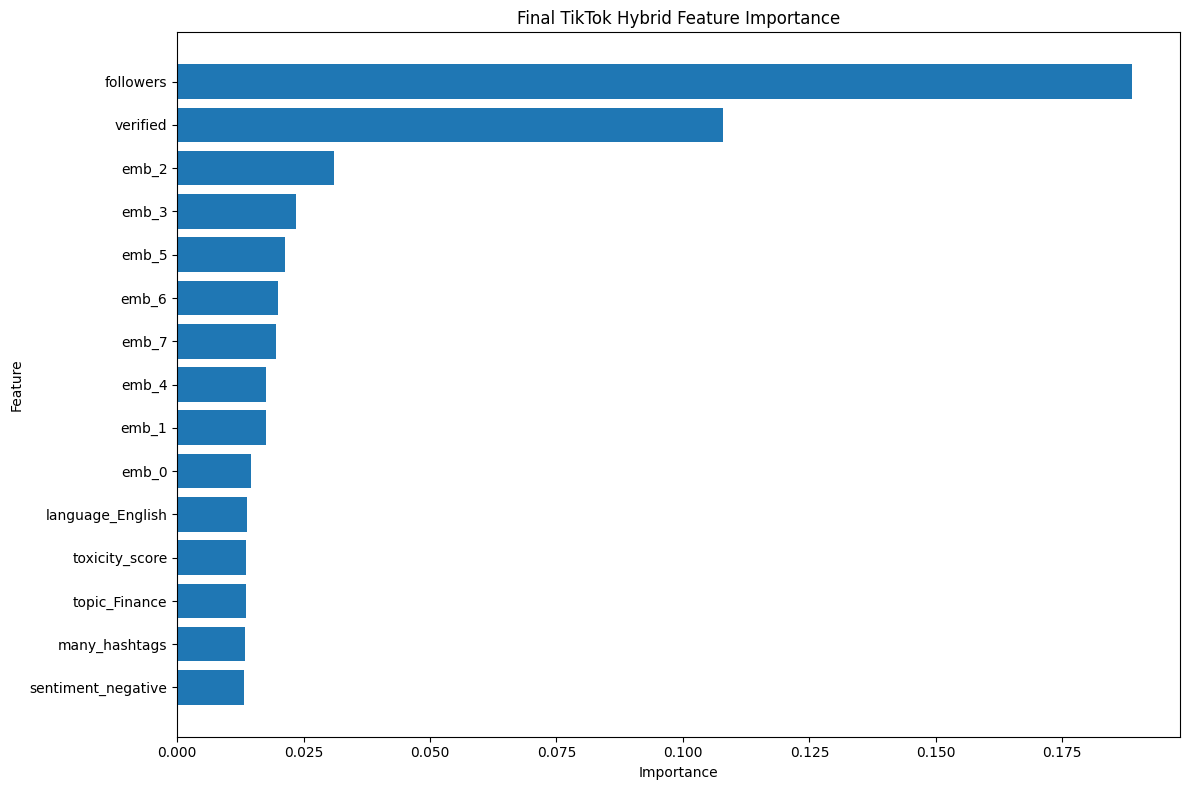

In [211]:
# PLOT FEATURE IMPORTANCE
# =====================================================

top_n = 15

plot_df = importance_df.head(top_n)

plt.figure(figsize=(12, 8))

plt.barh(

    plot_df["feature"][::-1],

    plot_df["importance"][::-1]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Final TikTok Hybrid Feature Importance"
)

plt.tight_layout()

plt.show()